
<font color="#CA3532"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Prueba de modelo YOLO26</h2></font>

#### David Alejandro Pedroza De Jesús

# Carga de librerias

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report, roc_auc_score, roc_curve,ConfusionMatrixDisplay
import seaborn as sns
import torch
from ultralytics import YOLO
import cv2
import shutil
from google.colab import drive

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:

drive.mount('/content/drive')

Mounted at /content/drive


#   Carga de modelo YOLO26 y algunos datos importantes

In [4]:
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [5]:
shutil.copy(
    "/content/drive/MyDrive/kaggle.zip",

    "/content/")



'/content/kaggle.zip'

In [6]:
shutil.copytree(
    "/content/drive/MyDrive/runstf_8",
    "/content/runstf_8")

'/content/runstf_8'

In [7]:
!unzip kaggle.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

In [8]:
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
#info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")
resultados = pd.read_csv("runstf_8/classify/train/results.csv")
model = YOLO("runstf_8/classify/train/weights/best.pt")
test = pd.merge(info_especies, rutas_test, on='label', how='inner')


Ahora voy a obtener predicciones del conjunto de test

In [9]:
def get_prediction(results,labels):
    results_ls = results[0]

    probs = results_ls.probs.data.cpu().numpy()

    prob_img = probs
    pred_img = prob_img.argmax()

    return pred_img, prob_img

In [10]:

labels = info_especies.label.unique()
y_true = []
y_pred = []
y_proba = []
for registro,real_name in zip(test.image_path,test.label):
    img = cv2.imread(registro[1:])
    results = model(img)
    results_ls = results[0]
    y_true.append(int(np.where(labels == real_name)[0][0]))
    pred, prob = get_prediction(results,labels)
    y_pred.append(pred)
    y_proba.append(prob)


Se han truncado las últimas 5000 líneas del flujo de salida.
0: 256x256 Lycoperdon perlatum 1.00, Amanita rubescens 0.00, Coprinellus micaceus 0.00, Paxillus involutus 0.00, Amanita pantherina 0.00, 13.4ms
Speed: 9.4ms preprocess, 13.4ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Lycoperdon perlatum 1.00, Macrolepiota procera 0.00, Phallus impudicus 0.00, Coprinus comatus 0.00, Amanita pantherina 0.00, 11.5ms
Speed: 9.6ms preprocess, 11.5ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Lycoperdon perlatum 1.00, Hericium erinaceus 0.00, Agaricus augustus 0.00, Trichaptum biforme 0.00, Leucoagaricus americanus 0.00, 6.6ms
Speed: 8.8ms preprocess, 6.6ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Lycoperdon perlatum 1.00, Lycoperdon pyriforme 0.00, Tricholomopsis rutilans 0.00, Leucoagaricus americanus 0.00, Amanita rubescens 0.00, 7.1ms
Speed: 7.1ms preprocess, 7.1ms inference, 0.1ms postpro

#   Graficos importantes para determinar el rendimientos
##  Loss

Vemos que la función de perdida del modelo decrece conforme las epocas van pasando, más o menos parece que con 12 epocas de entrenamiento son suficientes, ya que usando más el modelo no mejora.

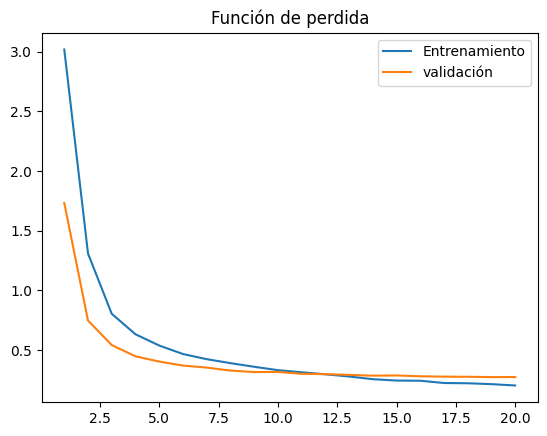

In [11]:
plt.plot(resultados.epoch,resultados["train/loss"], label = "Entrenamiento")
plt.plot(resultados.epoch,resultados["val/loss"], label = "validación")
plt.legend(loc="upper right")
plt.title("Función de perdida")
plt.show()

##  Matriz de confución
### Versión normal
Vemos que además el modelo no parece requerir un ajuste de umbral debido a que todas las clases de predicen con un cierto exito

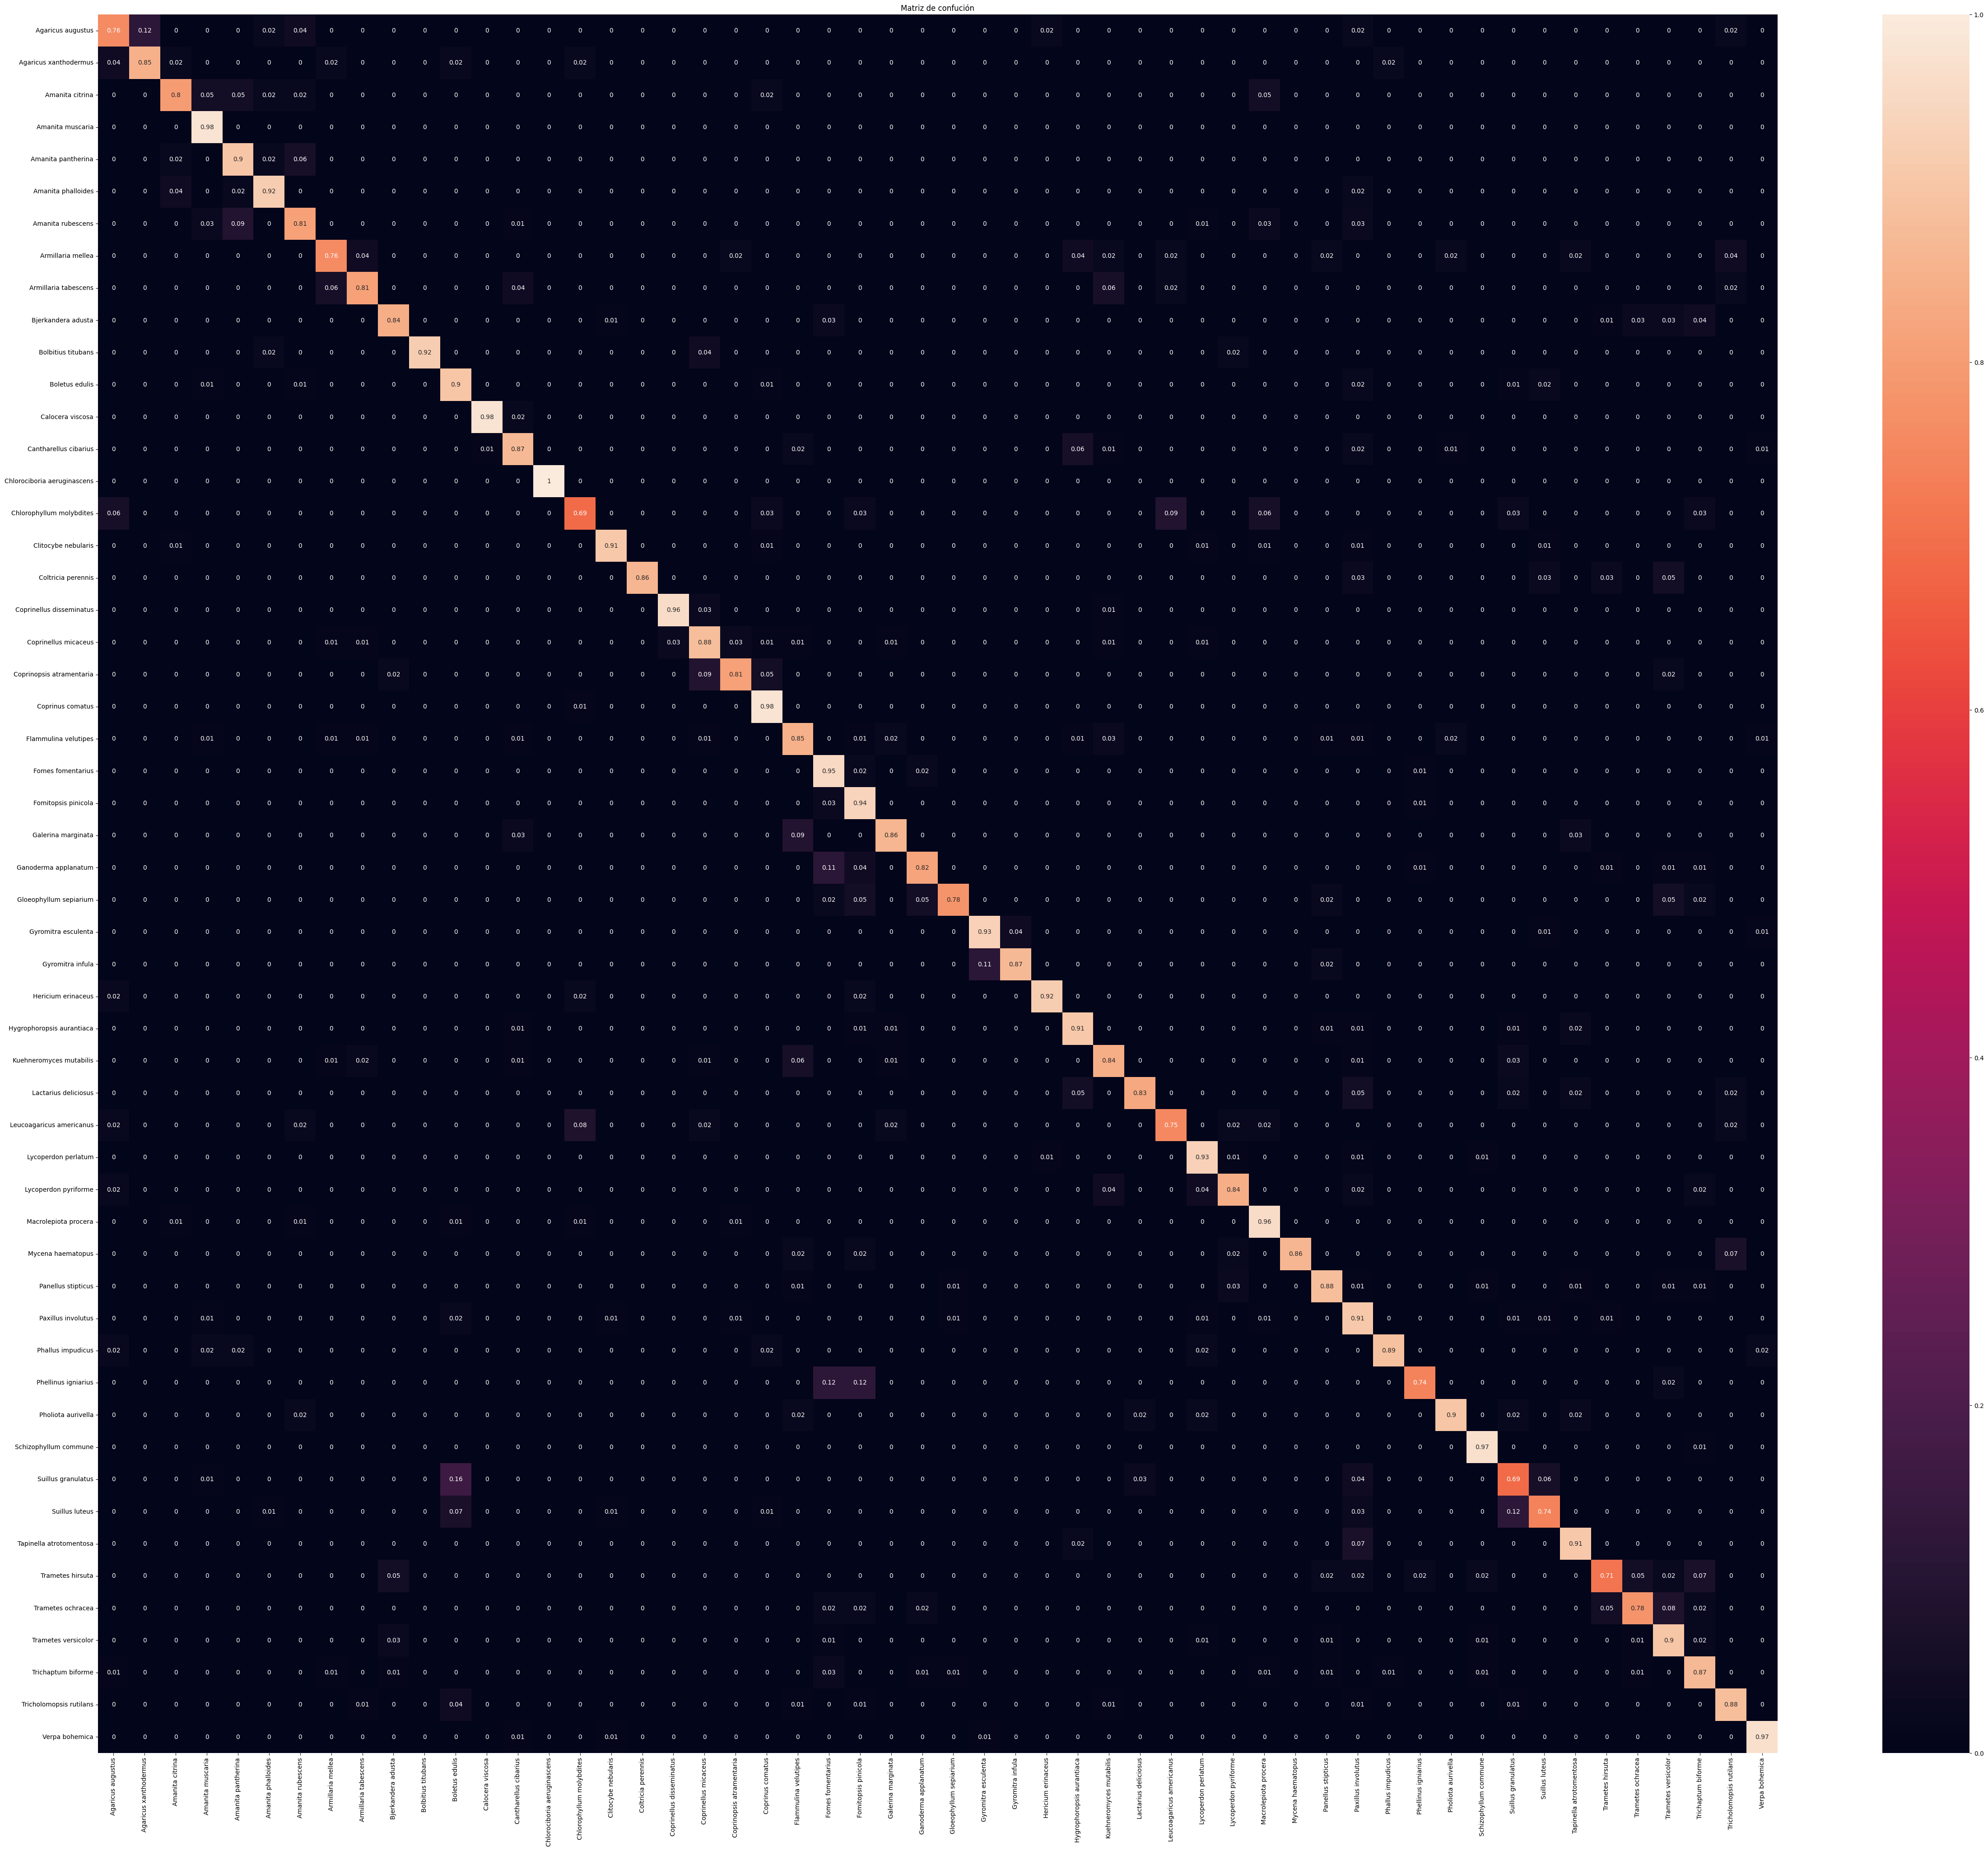

In [12]:
cm = confusion_matrix(y_true, y_pred, normalize= "true").round(2)
plt.subplots(figsize=(60,50))
sns.heatmap(cm,xticklabels= labels, yticklabels= labels,annot=True)
plt.title("Matriz de confución")
plt.show()

### Versión veneno

In [13]:
y_3_true = test.Info
y_3_pre = pd.merge(info_especies, pd.DataFrame(labels[y_pred],columns= ["label"]), on='label', how='inner')["Info"]

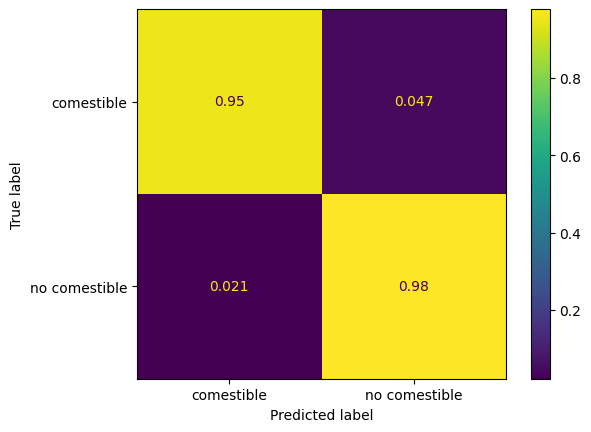

In [14]:
cm_3 = confusion_matrix(y_3_true, y_3_pre, normalize= "true")
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_3,display_labels= y_3_true.unique())
cm_display.plot()
plt.show()

##  Curva ROC

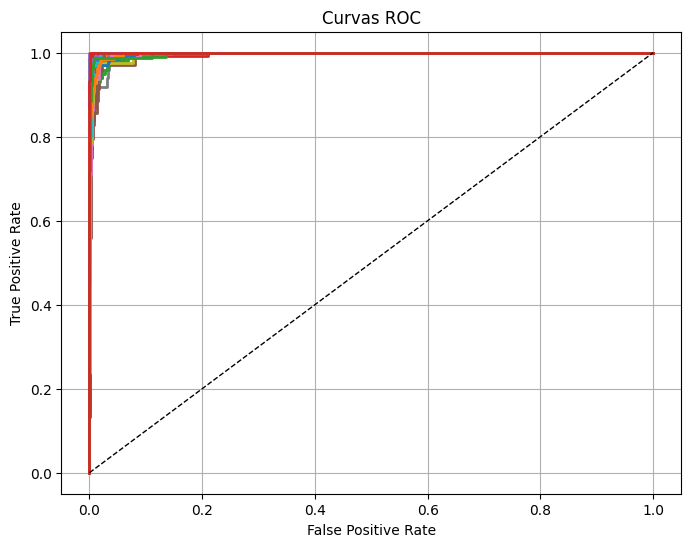

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_proba = np.array(y_proba)
n_classes = y_proba.shape[1]
y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
#plt.legend()
plt.grid(True)
plt.show()

##  Metricas básicas
### Para especies

In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.76      0.79        51
           1       0.83      0.85      0.84        46
           2       0.80      0.80      0.80        44
           3       0.98      0.98      0.98       687
           4       0.77      0.90      0.83        51
           5       0.90      0.92      0.91        48
           6       0.85      0.81      0.83        79
           7       0.82      0.76      0.79        49
           8       0.84      0.81      0.83        53
           9       0.86      0.84      0.85        70
          10       1.00      0.92      0.96        48
          11       0.87      0.90      0.88       220
          12       0.98      0.98      0.98        63
          13       0.92      0.87      0.90       126
          14       1.00      1.00      1.00        51
          15       0.75      0.69      0.72        35
          16       0.94      0.91      0.93        68
          17       1.00    

### Para comestibilidad

In [17]:
print(classification_report(y_3_true, y_3_pre))

               precision    recall  f1-score   support

   comestible       0.96      0.95      0.96      2311
no comestible       0.97      0.98      0.98      4131

     accuracy                           0.97      6442
    macro avg       0.97      0.97      0.97      6442
 weighted avg       0.97      0.97      0.97      6442

